# Chapter 17 - Structural Breaks

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import random

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm, moment
import statsmodels.api as sm

from utils.sampling_bars import dollar_bar
from utils.structural_break import (
    bde_recursive_residual_cusum,
    chow_type_dickey_fuller_test,
    csw_cusum_test,
    sub_super_martingale_test,
    supremum_adf_test,
)

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

In [2]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low
date,,,,,,,,
2009-09-28 09:31:50,50.75,50.73,50.76,300.0,15225.00,1.0,50.75,50.75
2009-09-28 09:33:02,50.81,50.80,50.81,800.0,40648.00,2.0,50.81,50.81
2009-09-28 09:34:04,50.82,50.80,50.82,100.0,5082.00,1.0,50.82,50.82
2009-09-28 09:38:28,50.81,50.79,50.81,195.0,9907.95,1.0,50.81,50.81
2009-09-28 09:42:17,50.85,50.83,50.85,200.0,10170.00,2.0,50.85,50.85


<Axes: xlabel='date'>

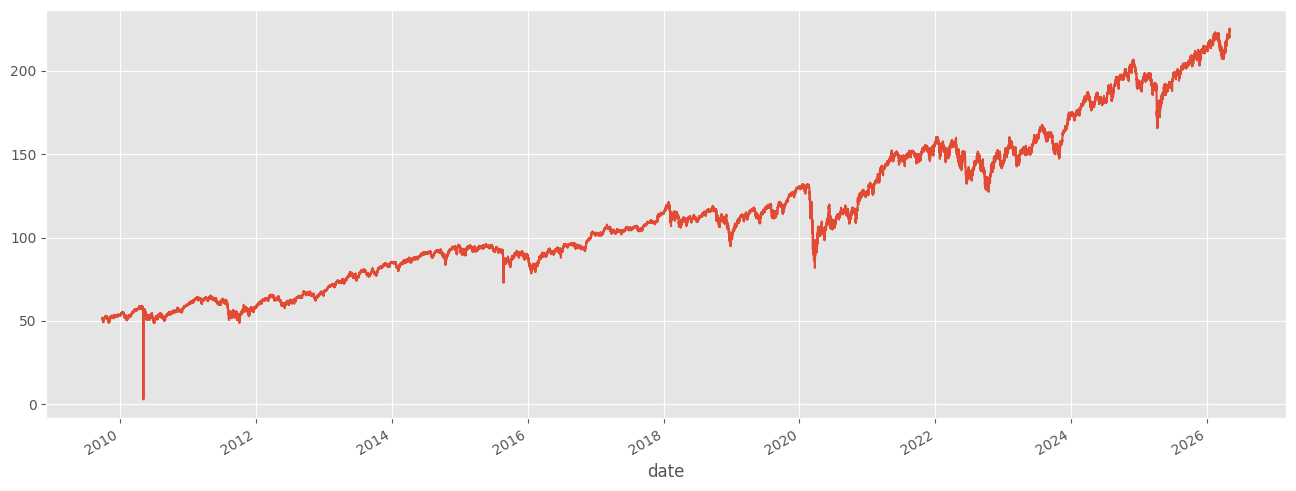

In [3]:
dollar_bars["price"].plot()

## 1. On a dollar bar series on E-mini S&P 500 futures,

### a. Apply the Brown-Durbin-Evans method. Does it recognize the dot-com bubble?

Note: the local file loaded in this notebook is IVE tick data beginning in 2009, not E-mini S&P 500 futures covering the dot-com period. The code below checks the mechanics of the BDE recursive-residual CUSUM test on the available sample; it cannot answer the dot-com-bubble question from this data.

In [4]:
# Log prices and returns
dollar_bars['log_price'] = np.log(dollar_bars['price'])
dollar_bars['log_ret'] = dollar_bars['log_price'].diff()
dollar_bars['log_t1'] = dollar_bars['log_ret'].shift(1)

# Prevent look-ahead bias: momentum uses prices available before the current return.
shifted_price = dollar_bars['price'].shift(1)
dollar_bars['mom2'] = shifted_price.pct_change(periods=2)
dollar_bars['mom5'] = shifted_price.pct_change(periods=5)

# Volatility
dollar_bars['volatility_15'] = dollar_bars['log_t1'].rolling(window=15, min_periods=15).std()
dollar_bars['volatility_50'] = dollar_bars['log_t1'].rolling(window=50, min_periods=50).std()

# Serial correlation. This is equivalent to rolling.apply(lambda x: x.autocorr(lag)),
# but avoids a very slow Python callback for every rolling window.
def rolling_autocorr(series, window, lag):
    if lag <= 0 or lag >= window:
        raise ValueError('lag must be positive and smaller than window')
    pair_window = window - lag
    return series.rolling(window=pair_window, min_periods=pair_window).corr(series.shift(lag))

window_autocorr = 100
dollar_bars['autocorr_2'] = rolling_autocorr(dollar_bars['log_t1'], window_autocorr, lag=2)
dollar_bars['autocorr_4'] = rolling_autocorr(dollar_bars['log_t1'], window_autocorr, lag=4)

In [5]:
feature_cols = ['volatility_50', 'volatility_15', 'autocorr_2', 'autocorr_4', 'mom2', 'mom5']
test_data = dollar_bars[['price', 'log_price', 'log_ret', *feature_cols]].dropna()

print(f'Test sample: {test_data.index.min()} to {test_data.index.max()}')
print(f'Number of dollar bars in test sample: {len(test_data):,}')

Test sample: 2009-09-28 11:30:52 to 2026-05-01 16:00:00
Number of dollar bars in test sample: 1,443,590


In [6]:
# Use a non-trivial initial estimation window so the recursive model is not seeded
# by only one barely identified regression fit. The crossing date is still a CUSUM
# boundary event, not a timestamp where price itself must jump.
initial_observations = max(len(feature_cols) + 1, 10_000)
initial_observations = min(initial_observations, len(test_data) - 2)

bde = bde_recursive_residual_cusum(
    y=test_data['log_ret'],
    X=test_data[feature_cols],
    initial=initial_observations,
    conf_level=0.95,
    add_intercept=True,
)

In [7]:
print(f'Reject stability: {bde.attrs["reject"]}')
print(f'First crossing: {bde.attrs["first_crossing"]}')
print(f'Initial observations: {bde.attrs["initial_observations"]:,}')
print(f'Initial window ends: {test_data.index[bde.attrs["initial_observations"] - 1]}')
print(f'Recursive residual mean: {bde.attrs["recursive_resid_mean"]:.3e}')
print(f'Recursive residual std: {bde.attrs["sigma_hat"]:.3e}')

Reject stability: True
First crossing: 2014-02-19 10:18:12
Initial observations: 10,000
Initial window ends: 2009-12-17 12:08:41
Recursive residual mean: 1.532e-05
Recursive residual std: 3.288e-03


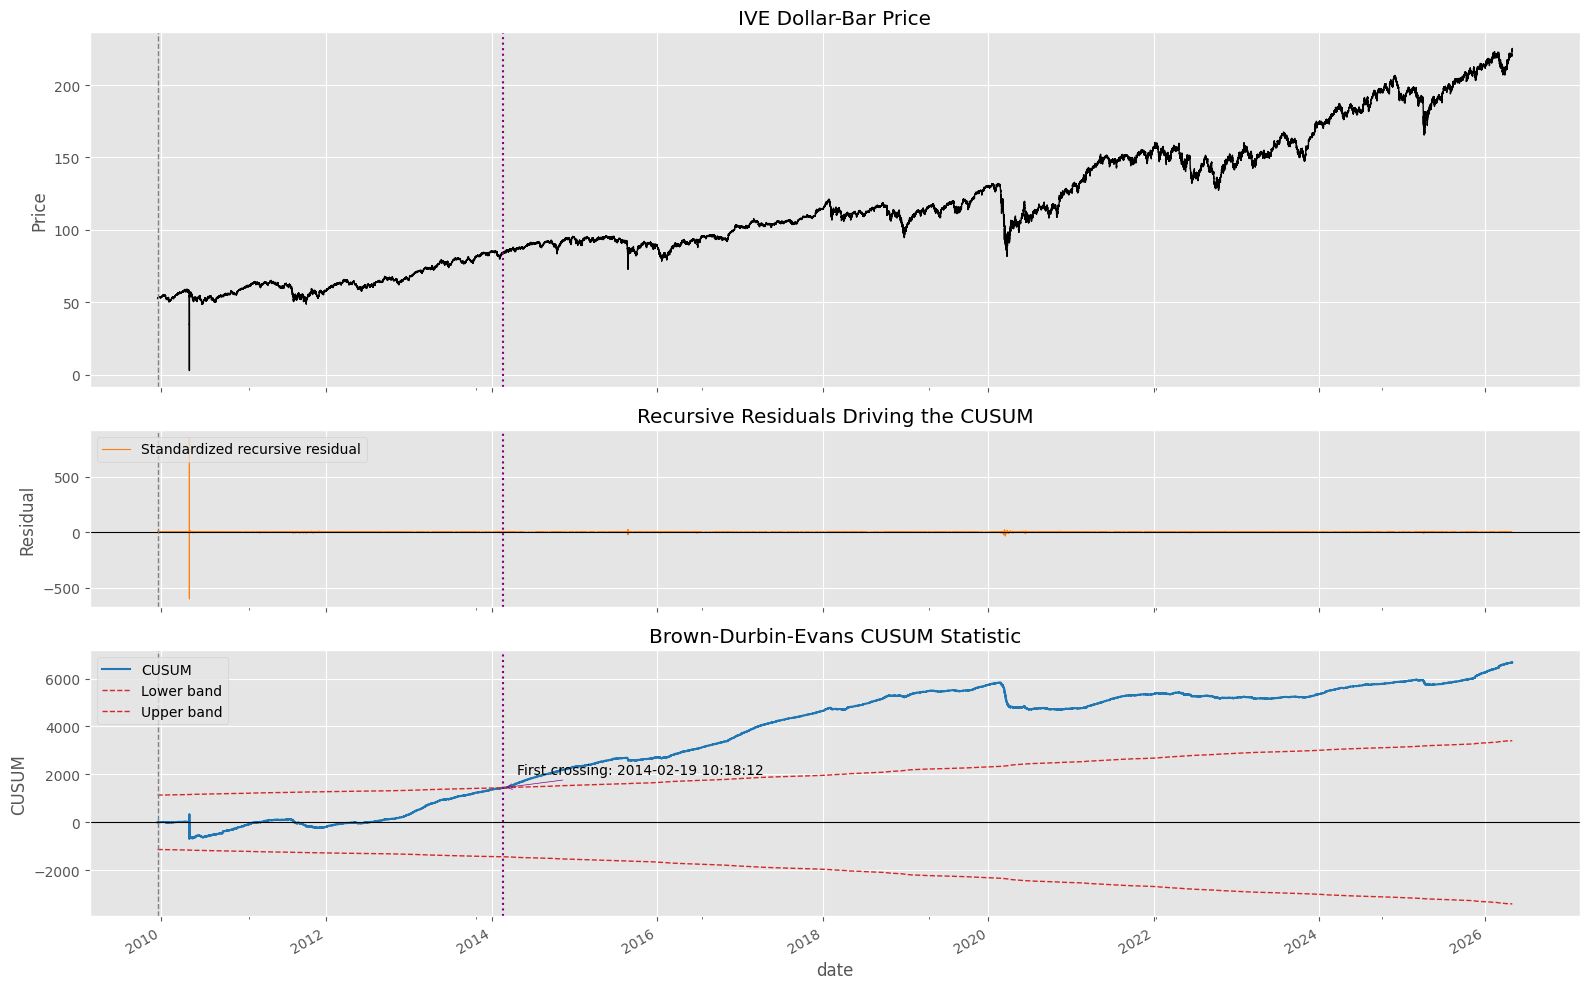

In [8]:
plot_df = bde.join(test_data[['price', 'log_ret']], how='left')
first_crossing = bde.attrs['first_crossing']
initial_end = test_data.index[bde.attrs['initial_observations'] - 1]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1, 1.5]},
)

plot_df['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title('IVE Dollar-Bar Price')
axes[0].set_ylabel('Price')

plot_df['std_recursive_resid'].plot(ax=axes[1], color='tab:orange', linewidth=0.8, label='Standardized recursive residual')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Recursive Residuals Driving the CUSUM')
axes[1].set_ylabel('Residual')
axes[1].legend(loc='upper left')

plot_df['cusum'].plot(ax=axes[2], color='tab:blue', linewidth=1.5, label='CUSUM')
plot_df['lower'].plot(ax=axes[2], color='tab:red', linestyle='--', linewidth=1, label='Lower band')
plot_df['upper'].plot(ax=axes[2], color='tab:red', linestyle='--', linewidth=1, label='Upper band')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Brown-Durbin-Evans CUSUM Statistic')
axes[2].set_ylabel('CUSUM')
axes[2].legend(loc='upper left')

for ax in axes:
    ax.axvline(initial_end, color='gray', linewidth=1, linestyle='--')

if first_crossing is not None:
    for ax in axes:
        ax.axvline(first_crossing, color='purple', linewidth=1.5, linestyle=':')
    axes[2].annotate(
        f'First crossing: {first_crossing}',
        xy=(first_crossing, plot_df.loc[first_crossing, 'cusum']),
        xytext=(10, 10),
        textcoords='offset points',
        arrowprops={'arrowstyle': '->', 'color': 'purple'},
    )

plt.tight_layout()
plt.show()

### b. Apply the Chu-Stinchcombe-White method. Does it find a bubble in  2007–2008?

Note: the local IVE sample starts in 2009, so it cannot test for a 2007–2008 bubble. The code below applies the CSW statistic to daily closes from the available sample.

Reject one-sided CSW: True
First crossing: 2010-05-10 00:00:00
Observations: 4,174


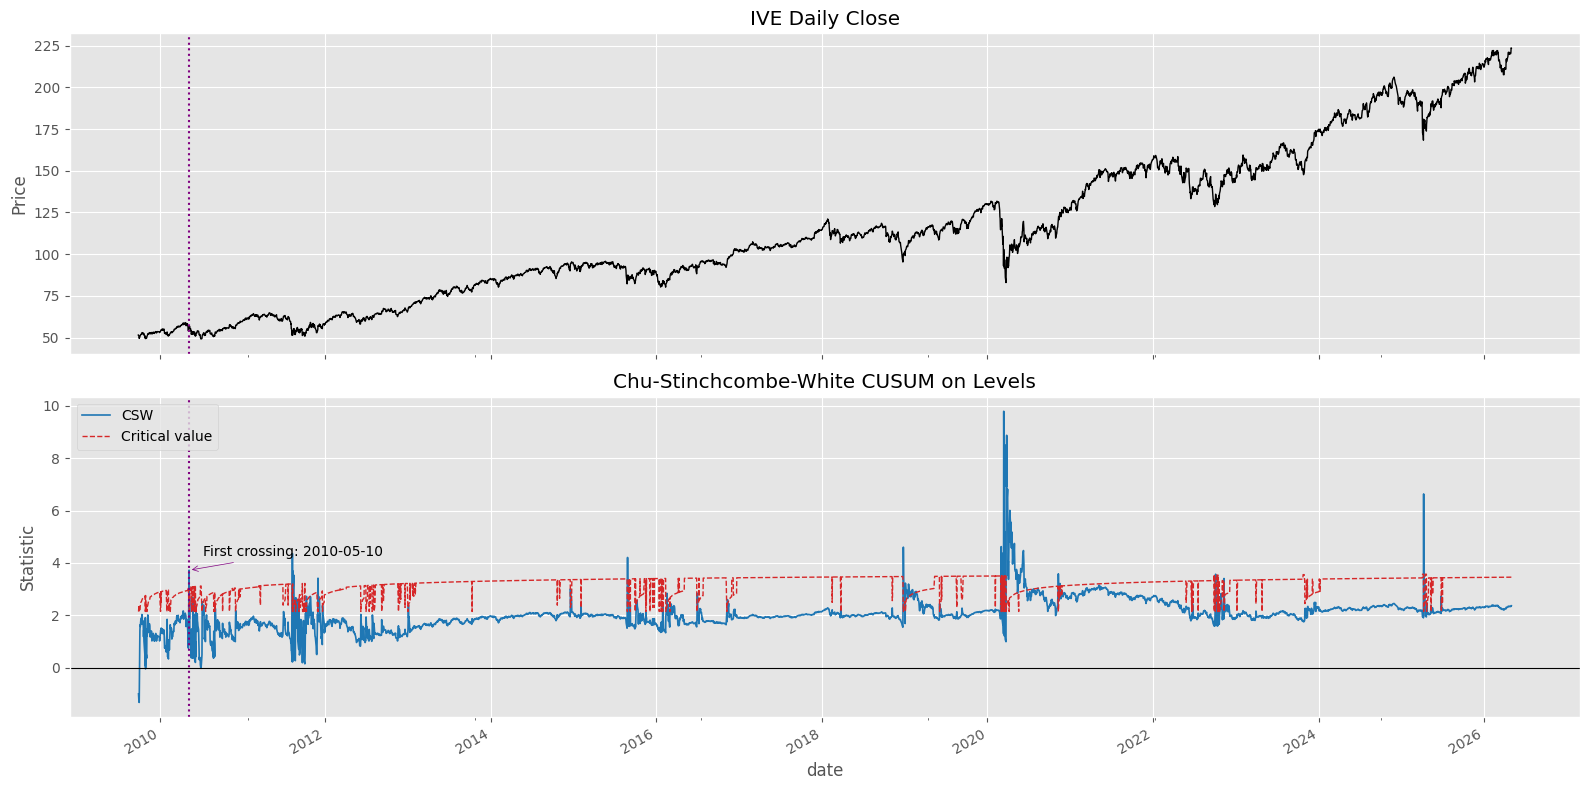

In [9]:
csw_data = test_data[['price', 'log_price']].resample('1D').last().dropna()
csw = csw_cusum_test(csw_data['log_price'])

print(f'Reject one-sided CSW: {csw.attrs["reject"]}')
print(f'First crossing: {csw.attrs["first_crossing"]}')
print(f'Observations: {csw.attrs["nobs"]:,}')

csw_plot_df = csw.join(csw_data[['price']], how='left')
first_csw_crossing = csw.attrs['first_crossing']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

csw_plot_df['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].set_title('IVE Daily Close')
axes[0].set_ylabel('Price')

csw_plot_df['csw'].plot(ax=axes[1], color='tab:blue', linewidth=1.2, label='CSW')
csw_plot_df['critical'].plot(ax=axes[1], color='tab:red', linestyle='--', linewidth=1, label='Critical value')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Chu-Stinchcombe-White CUSUM on Levels')
axes[1].set_ylabel('Statistic')
axes[1].legend(loc='upper left')

if first_csw_crossing is not None:
    for ax in axes:
        ax.axvline(first_csw_crossing, color='purple', linewidth=1.5, linestyle=':')
    axes[1].annotate(
        f'First crossing: {first_csw_crossing.date()}',
        xy=(first_csw_crossing, csw_plot_df.loc[first_csw_crossing, 'csw']),
        xytext=(10, 10),
        textcoords='offset points',
        arrowprops={'arrowstyle': '->', 'color': 'purple'},
    )

plt.tight_layout()
plt.show()

## 2. On a dollar bar series on E-mini S&P 500 futures,

### a. Compute the SDFC (Chow-type) explosiveness test. What break date does this method select? Is this what you expected?

Note: this notebook uses the local IVE dollar-bar sample, not E-mini S&P 500 futures. The selected break date below answers the available-sample mechanics rather than the original futures-data framing.

SDFC statistic: 0.3548
Selected break date: 2020-03-23 15:36:07
Selected break location: 783512 (54.27% of sample)
Sample size: 1,443,691
Trim fraction: 15%


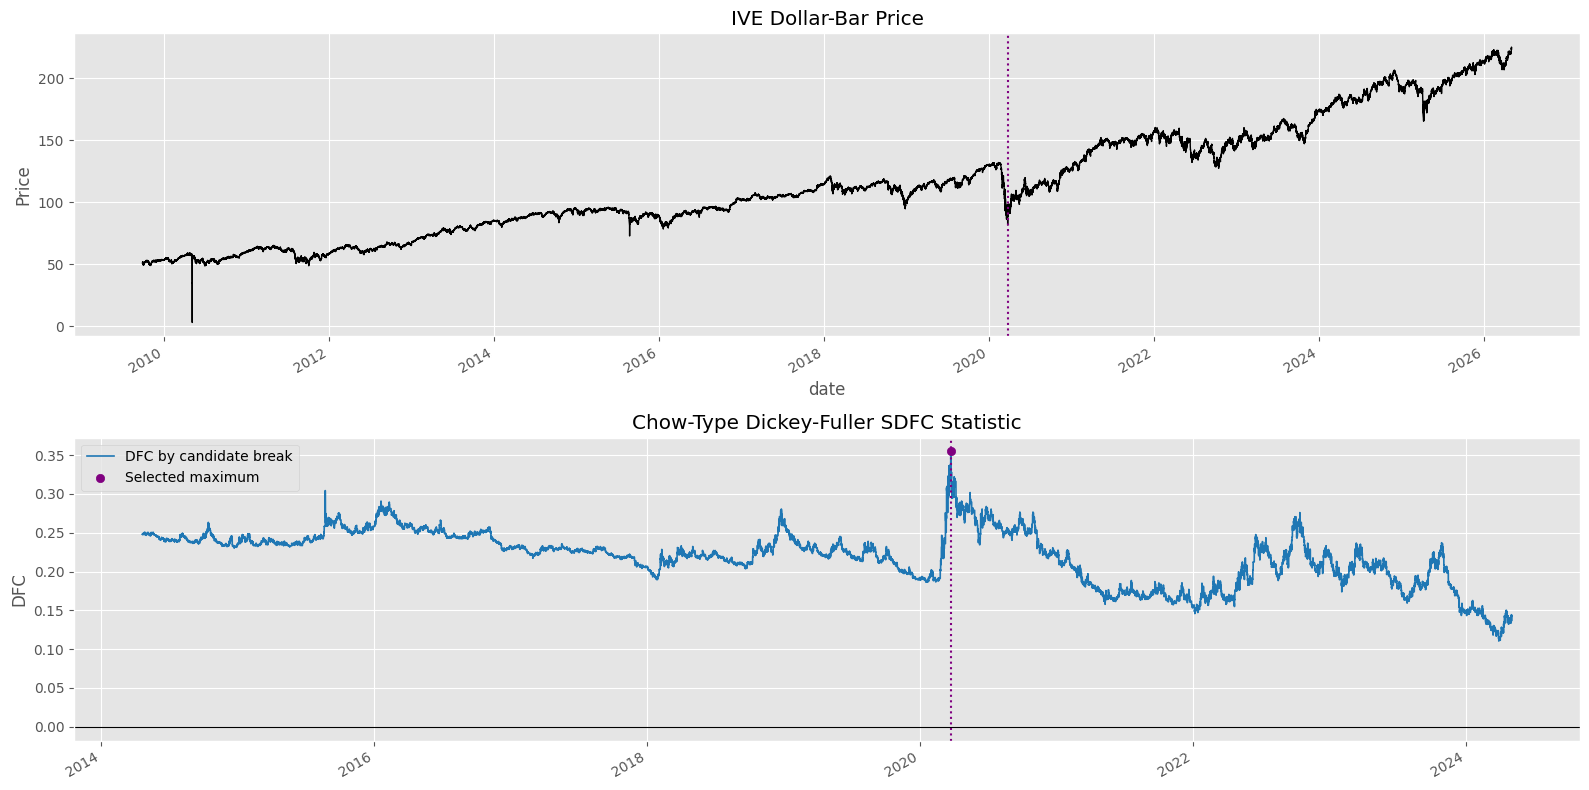

In [10]:
sdfc = chow_type_dickey_fuller_test(dollar_bars["log_price"].dropna(), min_fraction=0.15)
selected_row = sdfc[sdfc['selected']].iloc[0]
selected_break = sdfc.attrs['break_date']

print(f'SDFC statistic: {sdfc.attrs["sdfc"]:.4f}')
print(f'Selected break date: {selected_break}')
print(f'Selected break location: {sdfc.attrs["break_loc"]} ({selected_row["tau"]:.2%} of sample)')
print(f'Sample size: {sdfc.attrs["nobs"]:,}')
print(f'Trim fraction: {sdfc.attrs["min_fraction"]:.0%}')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

dollar_bars['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].axvline(selected_break, color='purple', linewidth=1.5, linestyle=':')
axes[0].set_title('IVE Dollar-Bar Price')
axes[0].set_ylabel('Price')

sdfc['dfc'].plot(ax=axes[1], color='tab:blue', linewidth=1.2, label='DFC by candidate break')
axes[1].scatter([selected_break], [selected_row['dfc']], color='purple', zorder=3, label='Selected maximum')
axes[1].axvline(selected_break, color='purple', linewidth=1.5, linestyle=':')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Chow-Type Dickey-Fuller SDFC Statistic')
axes[1].set_ylabel('DFC')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### b. Compute and plot the SADF values for this series. Do you observe extreme spikes around the dot-com bubble and before the Great Recession? Did the bursts also cause spikes?

Note: this notebook's local IVE sample starts on 2009-09-28. It cannot test the dot-com bubble or the pre-Great-Recession period without a longer dataset.

SADF maximum: 3.5006
Maximum date: 2020-03-23
Window start at maximum: 2019-04-24 00:00:00
Window observations at maximum: 231
Lags: 1
Minimum ADF window length: 209
Daily sample: 2009-09-28 to 2026-05-01 (4,174 observations)
The local sample starts after the dot-com bubble and after the 2007-2009 Great Recession, so those book-period spikes require a longer dataset.


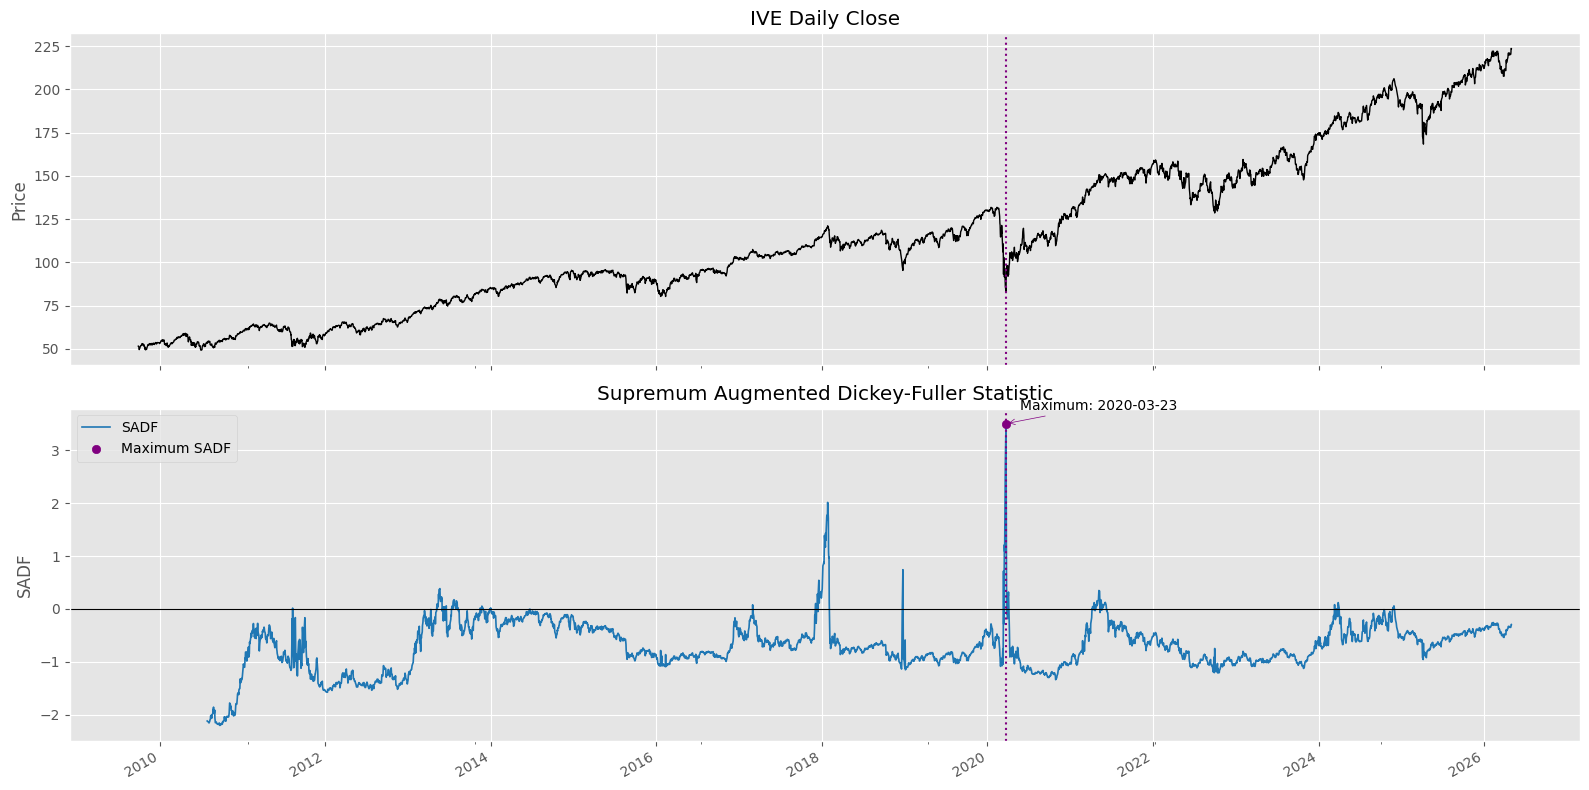

In [11]:
sadf_data = test_data[['price', 'log_price']].resample('1D').last().dropna()

sadf_lags = 1
sadf_min_length = max(30, round(0.05 * len(sadf_data)))
sadf = supremum_adf_test(
    sadf_data['log_price'],
    min_length=sadf_min_length,
    lags=sadf_lags,
)

max_sadf_date = sadf['sadf'].idxmax()
max_sadf_row = sadf.loc[max_sadf_date]
max_sadf_value = max_sadf_row['sadf']
max_sadf_start = max_sadf_row['start']
max_sadf_nobs = int(max_sadf_row['nobs'])

print(f'SADF maximum: {max_sadf_value:.4f}')
print(f'Maximum date: {max_sadf_date.date()}')
print(f'Window start at maximum: {max_sadf_start}')
print(f'Window observations at maximum: {max_sadf_nobs:,}')
print(f'Lags: {sadf.attrs["lags"]}')
print(f'Minimum ADF window length: {sadf.attrs["min_length"]:,}')
print(f'Daily sample: {sadf_data.index.min().date()} to {sadf_data.index.max().date()} ({len(sadf_data):,} observations)')
print('The local sample starts after the dot-com bubble and after the 2007-2009 Great Recession, so those book-period spikes require a longer dataset.')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

sadf_data['price'].plot(ax=axes[0], color='black', linewidth=1)
axes[0].axvline(max_sadf_date, color='purple', linewidth=1.5, linestyle=':')
axes[0].set_title('IVE Daily Close')
axes[0].set_ylabel('Price')

sadf['sadf'].plot(ax=axes[1], color='tab:blue', linewidth=1.2, label='SADF')
axes[1].scatter([max_sadf_date], [max_sadf_value], color='purple', zorder=3, label='Maximum SADF')
axes[1].axvline(max_sadf_date, color='purple', linewidth=1.5, linestyle=':')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Supremum Augmented Dickey-Fuller Statistic')
axes[1].set_ylabel('SADF')
axes[1].legend(loc='upper left')
axes[1].annotate(
    f'Maximum: {max_sadf_date.date()}',
    xy=(max_sadf_date, max_sadf_value),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops={'arrowstyle': '->', 'color': 'purple'},
)

plt.tight_layout()
plt.show()

## 3. Following on exercise 2,

### a. Determine the periods where the series exhibited
* i. Steady conditions 
* ii. Unit-Root conditions 
* iii. Explosive conditions

The classification below treats the three regimes as statistical decisions against a unit-root null. A raw beta sign is not enough, because a small positive or negative beta can be sampling noise.

For each endpoint date, we estimate ADF windows ending at that date and keep two statistics:

* `right_adf`: the largest beta t-statistic across candidate starts. Large values indicate explosive behavior.
* `left_adf`: the smallest beta t-statistic across candidate starts. Very negative values indicate steady or stationary behavior.

Because both statistics search across many candidate windows, their critical values are simulated under a unit-root process with the same sample length, lag order, intercept choice, and minimum window length as the real SADF calculation. The final classifier also enforces the beta sign: explosive labels require a positive selected beta, and steady labels require a negative selected beta. Increase `n_sims` when you want more stable final numbers; the default below is kept moderate so the notebook remains practical to rerun.


In [12]:
def endpoint_adf_extrema(y, min_length, lags, add_intercept=True):
    """
    For each endpoint, compute both the right-tail and left-tail ADF extrema
    over all valid backward-looking start dates.

    This mirrors supremum_adf_test for the right tail, and adds the matching
    infimum statistic needed to separate steady from unit-root periods.
    """
    if isinstance(lags, bool) or not isinstance(lags, (int, np.integer)):
        raise TypeError("lags must be an integer")
    if lags < 0:
        raise ValueError("lags must be non-negative")
    if isinstance(min_length, bool) or not isinstance(min_length, (int, np.integer)):
        raise TypeError("min_length must be an integer")
    if min_length <= 0:
        raise ValueError("min_length must be positive")

    y = pd.Series(y).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(y) < lags + 3:
        raise ValueError("y is too short for the requested lag order")

    dy = y.diff()
    data = pd.DataFrame({"dy": dy, "y_lag": y.shift(1)})
    for lag in range(1, lags + 1):
        data[f"dy_lag_{lag}"] = dy.shift(lag)
    data = data.dropna()
    if data.empty:
        raise ValueError("No usable ADF regression rows remain after lagging")

    z = data["dy"].to_numpy(dtype=float)
    regressors = data.drop(columns="dy").to_numpy(dtype=float)
    if add_intercept:
        X = np.column_stack([np.ones(len(regressors)), regressors])
        beta_col = 1
    else:
        X = regressors
        beta_col = 0

    nobs, nvars = X.shape
    if nobs < min_length:
        raise ValueError("Not enough usable observations for min_length")
    if min_length <= nvars:
        raise ValueError("min_length must exceed the number of regressors")
    if z.std(ddof=0) <= 0:
        raise ValueError("First differences must have positive variance")

    xx = X[:, :, None] * X[:, None, :]
    xy = X * z[:, None]
    yy = z * z
    prefix_xx = np.concatenate([np.zeros((1, nvars, nvars)), np.cumsum(xx, axis=0)], axis=0)
    prefix_xy = np.concatenate([np.zeros((1, nvars)), np.cumsum(xy, axis=0)], axis=0)
    prefix_yy = np.r_[0.0, np.cumsum(yy)]

    endpoint_locs = np.arange(min_length - 1, nobs)
    right_stat = np.full(len(endpoint_locs), np.nan)
    left_stat = np.full(len(endpoint_locs), np.nan)
    right_start = np.full(len(endpoint_locs), -1)
    left_start = np.full(len(endpoint_locs), -1)
    right_beta = np.full(len(endpoint_locs), np.nan)
    left_beta = np.full(len(endpoint_locs), np.nan)
    right_beta_se = np.full(len(endpoint_locs), np.nan)
    left_beta_se = np.full(len(endpoint_locs), np.nan)
    right_nobs = np.full(len(endpoint_locs), np.nan)
    left_nobs = np.full(len(endpoint_locs), np.nan)

    eps = np.finfo(float).eps

    for row_pos, end_loc in enumerate(endpoint_locs):
        start_locs = np.arange(0, end_loc - min_length + 2)
        window_nobs = end_loc - start_locs + 1

        xtx = prefix_xx[end_loc + 1] - prefix_xx[start_locs]
        xty = prefix_xy[end_loc + 1] - prefix_xy[start_locs]
        yty = prefix_yy[end_loc + 1] - prefix_yy[start_locs]

        det = np.linalg.det(xtx)
        scale = np.linalg.norm(xtx, ord=np.inf, axis=(1, 2))
        rank_threshold = eps * np.maximum(scale, 1.0) ** nvars
        valid = (window_nobs > nvars) & np.isfinite(det) & (np.abs(det) > rank_threshold)
        if not np.any(valid):
            continue

        beta = np.full((len(start_locs), nvars), np.nan)
        inv_xtx = np.full_like(xtx, np.nan)
        try:
            beta[valid] = np.linalg.solve(xtx[valid], xty[valid][..., None]).squeeze(-1)
            inv_xtx[valid] = np.linalg.inv(xtx[valid])
        except np.linalg.LinAlgError:
            continue

        with np.errstate(divide="ignore", invalid="ignore"):
            rss = yty - np.einsum("ij,ij->i", beta, xty)
            rss = np.maximum(rss, 0.0)
            sigma2 = rss / (window_nobs - nvars)
            beta_se = np.sqrt(sigma2 * inv_xtx[:, beta_col, beta_col])
            adf_stat = beta[:, beta_col] / beta_se

        finite = valid & np.isfinite(adf_stat)
        if not np.any(finite):
            continue

        finite_stat = np.where(finite, adf_stat, np.nan)
        best_right = int(np.nanargmax(finite_stat))
        best_left = int(np.nanargmin(finite_stat))

        right_stat[row_pos] = adf_stat[best_right]
        left_stat[row_pos] = adf_stat[best_left]
        right_start[row_pos] = start_locs[best_right]
        left_start[row_pos] = start_locs[best_left]
        right_beta[row_pos] = beta[best_right, beta_col]
        left_beta[row_pos] = beta[best_left, beta_col]
        right_beta_se[row_pos] = beta_se[best_right]
        left_beta_se[row_pos] = beta_se[best_left]
        right_nobs[row_pos] = window_nobs[best_right]
        left_nobs[row_pos] = window_nobs[best_left]

    right_start_dates = np.full(len(endpoint_locs), np.nan, dtype=object)
    left_start_dates = np.full(len(endpoint_locs), np.nan, dtype=object)
    right_valid = right_start >= 0
    left_valid = left_start >= 0
    right_start_dates[right_valid] = data.index.to_numpy()[right_start[right_valid]]
    left_start_dates[left_valid] = data.index.to_numpy()[left_start[left_valid]]

    result = pd.DataFrame(
        {
            "right_adf": right_stat,
            "right_start": right_start_dates,
            "right_beta": right_beta,
            "right_beta_se": right_beta_se,
            "right_nobs": right_nobs,
            "left_adf": left_stat,
            "left_start": left_start_dates,
            "left_beta": left_beta,
            "left_beta_se": left_beta_se,
            "left_nobs": left_nobs,
        },
        index=data.index.to_numpy()[endpoint_locs],
    )
    result.attrs["lags"] = int(lags)
    result.attrs["min_length"] = int(min_length)
    result.attrs["add_intercept"] = bool(add_intercept)
    return result


def simulate_unit_root_critical_curves(index, min_length, lags, n_sims=50, alpha=0.05, seed=42, add_intercept=True, progress=True):
    """
    Simulate endpoint-level critical values under y_t = y_{t-1} + epsilon_t.

    The right-tail curve is used for explosive periods. The left-tail curve is
    used for steady/stationary periods. Anything between them is treated as a
    unit-root period.
    """
    rng = np.random.default_rng(seed)
    index = pd.Index(index)
    right_paths = []
    left_paths = []
    endpoint_index = None

    for sim in range(n_sims):
        if progress and (sim == 0 or (sim + 1) % max(1, n_sims // 5) == 0 or sim + 1 == n_sims):
            print(f"Simulating unit-root path {sim + 1}/{n_sims}")
        innovations = rng.standard_normal(len(index))
        y_sim = pd.Series(np.cumsum(innovations), index=index)
        sim_stats = endpoint_adf_extrema(
            y_sim,
            min_length=min_length,
            lags=lags,
            add_intercept=add_intercept,
        )
        if endpoint_index is None:
            endpoint_index = sim_stats.index
        right_paths.append(sim_stats["right_adf"].to_numpy())
        left_paths.append(sim_stats["left_adf"].to_numpy())

    right_paths = np.vstack(right_paths)
    left_paths = np.vstack(left_paths)
    critical = pd.DataFrame(
        {
            "right_critical": np.nanquantile(right_paths, 1 - alpha, axis=0),
            "left_critical": np.nanquantile(left_paths, alpha, axis=0),
        },
        index=endpoint_index,
    )
    critical.attrs["n_sims"] = int(n_sims)
    critical.attrs["alpha"] = float(alpha)
    critical.attrs["global_right_critical"] = float(np.nanquantile(np.nanmax(right_paths, axis=1), 1 - alpha))
    critical.attrs["global_left_critical"] = float(np.nanquantile(np.nanmin(left_paths, axis=1), alpha))
    return critical


def classify_regime_periods(stats, critical):
    classified = stats.join(critical, how="inner")
    classified["right_excess"] = classified["right_adf"] - classified["right_critical"]
    classified["left_excess"] = classified["left_critical"] - classified["left_adf"]

    explosive = (classified["right_excess"] > 0) & (classified["right_beta"] > 0)
    steady = (classified["left_excess"] > 0) & (classified["left_beta"] < 0)
    classified["regime"] = "unit-root"
    classified.loc[steady, "regime"] = "steady"
    classified.loc[explosive, "regime"] = "explosive"

    both = steady & explosive
    classified.loc[both & (classified["left_excess"] > classified["right_excess"]), "regime"] = "steady"
    classified.loc[both & (classified["right_excess"] >= classified["left_excess"]), "regime"] = "explosive"

    group_id = classified["regime"].ne(classified["regime"].shift()).cumsum()
    periods = (
        classified.assign(group_id=group_id)
        .groupby("group_id")
        .agg(
            regime=("regime", "first"),
            start=("regime", lambda x: x.index.min()),
            end=("regime", lambda x: x.index.max()),
            endpoint_obs=("regime", "size"),
            max_right_adf=("right_adf", "max"),
            min_left_adf=("left_adf", "min"),
            max_right_excess=("right_excess", "max"),
            max_left_excess=("left_excess", "max"),
        )
        .reset_index(drop=True)
    )
    periods["calendar_days"] = (periods["end"] - periods["start"]).dt.days + 1
    periods = periods[["regime", "start", "end", "endpoint_obs", "calendar_days", "max_right_adf", "min_left_adf", "max_right_excess", "max_left_excess"]]
    return classified, periods


In [13]:
regime_alpha = 0.05
n_sims = 50
min_period_obs = 3
use_global_critical = False  # Set to True for a stricter any-episode threshold.

regime_stats = endpoint_adf_extrema(
    sadf_data["log_price"],
    min_length=sadf_min_length,
    lags=sadf_lags,
)

# Sanity check: the right-tail statistic should match the SADF statistic from exercise 2.
common_idx = regime_stats.index.intersection(sadf.index)
max_sadf_diff = (regime_stats.loc[common_idx, "right_adf"] - sadf.loc[common_idx, "sadf"]).abs().max()
print(f"Max difference versus previous SADF calculation: {max_sadf_diff:.3e}")

critical_curves = simulate_unit_root_critical_curves(
    sadf_data.index,
    min_length=sadf_min_length,
    lags=sadf_lags,
    n_sims=n_sims,
    alpha=regime_alpha,
    seed=42,
)

critical_for_classification = critical_curves.copy()
if use_global_critical:
    critical_for_classification["right_critical"] = critical_curves.attrs["global_right_critical"]
    critical_for_classification["left_critical"] = critical_curves.attrs["global_left_critical"]

classified_regimes, raw_regime_periods = classify_regime_periods(regime_stats, critical_for_classification)
regime_periods_to_review = raw_regime_periods[
    (raw_regime_periods["regime"] != "unit-root")
    & (raw_regime_periods["endpoint_obs"] >= min_period_obs)
].copy()

regime_summary = (
    classified_regimes["regime"]
    .value_counts()
    .rename_axis("regime")
    .reset_index(name="endpoint_obs")
)
regime_summary["share"] = regime_summary["endpoint_obs"] / len(classified_regimes)

print(f"Monte Carlo simulations: {critical_curves.attrs['n_sims']}")
print(f"Pointwise alpha: {critical_curves.attrs['alpha']:.1%}")
print(f"Critical-value mode: {'global' if use_global_critical else 'pointwise'}")
print(f"Global right-tail critical value for any explosive episode: {critical_curves.attrs['global_right_critical']:.4f}")
print(f"Global left-tail critical value for any steady episode: {critical_curves.attrs['global_left_critical']:.4f}")

print("Endpoint classification summary:")
display(regime_summary)

print(f"Non-unit-root periods with at least {min_period_obs} endpoint observations:")
display(regime_periods_to_review)


Max difference versus previous SADF calculation: 0.000e+00
Simulating unit-root path 1/50
Simulating unit-root path 10/50
Simulating unit-root path 20/50
Simulating unit-root path 30/50
Simulating unit-root path 40/50
Simulating unit-root path 50/50
Monte Carlo simulations: 50
Pointwise alpha: 5.0%
Critical-value mode: pointwise
Global right-tail critical value for any explosive episode: 2.6515
Global left-tail critical value for any steady episode: -5.2107
Endpoint classification summary:


,regime,endpoint_obs,share
0,unit-root,3835,0.967457
1,steady,74,0.018668
2,explosive,55,0.013875


Non-unit-root periods with at least 3 endpoint observations:


,regime,start,end,endpoint_obs,calendar_days,max_right_adf,min_left_adf,max_right_excess,max_left_excess
1,explosive,2013-05-08,2013-05-21,10,14,0.385087,-1.814394,0.434453,-2.338490
3,explosive,2013-07-11,2013-07-16,4,6,0.060681,-1.672701,0.089997,-2.419917
5,explosive,2013-07-18,2013-07-26,7,9,0.175197,-1.586872,0.296147,-2.561555
11,steady,2015-08-14,2015-08-20,5,7,-0.567923,-4.999071,-1.080832,0.868920
15,steady,2017-09-01,2017-11-28,61,89,-0.445943,-5.756200,-0.674308,1.556250
17,explosive,2018-01-03,2018-02-01,21,30,2.013080,-2.812556,1.392041,-1.349951
21,steady,2019-10-23,2019-10-31,7,9,-0.797425,-4.157297,-1.005451,0.237686
25,explosive,2020-03-16,2020-03-25,8,10,3.500576,-2.960351,3.091013,-1.132035


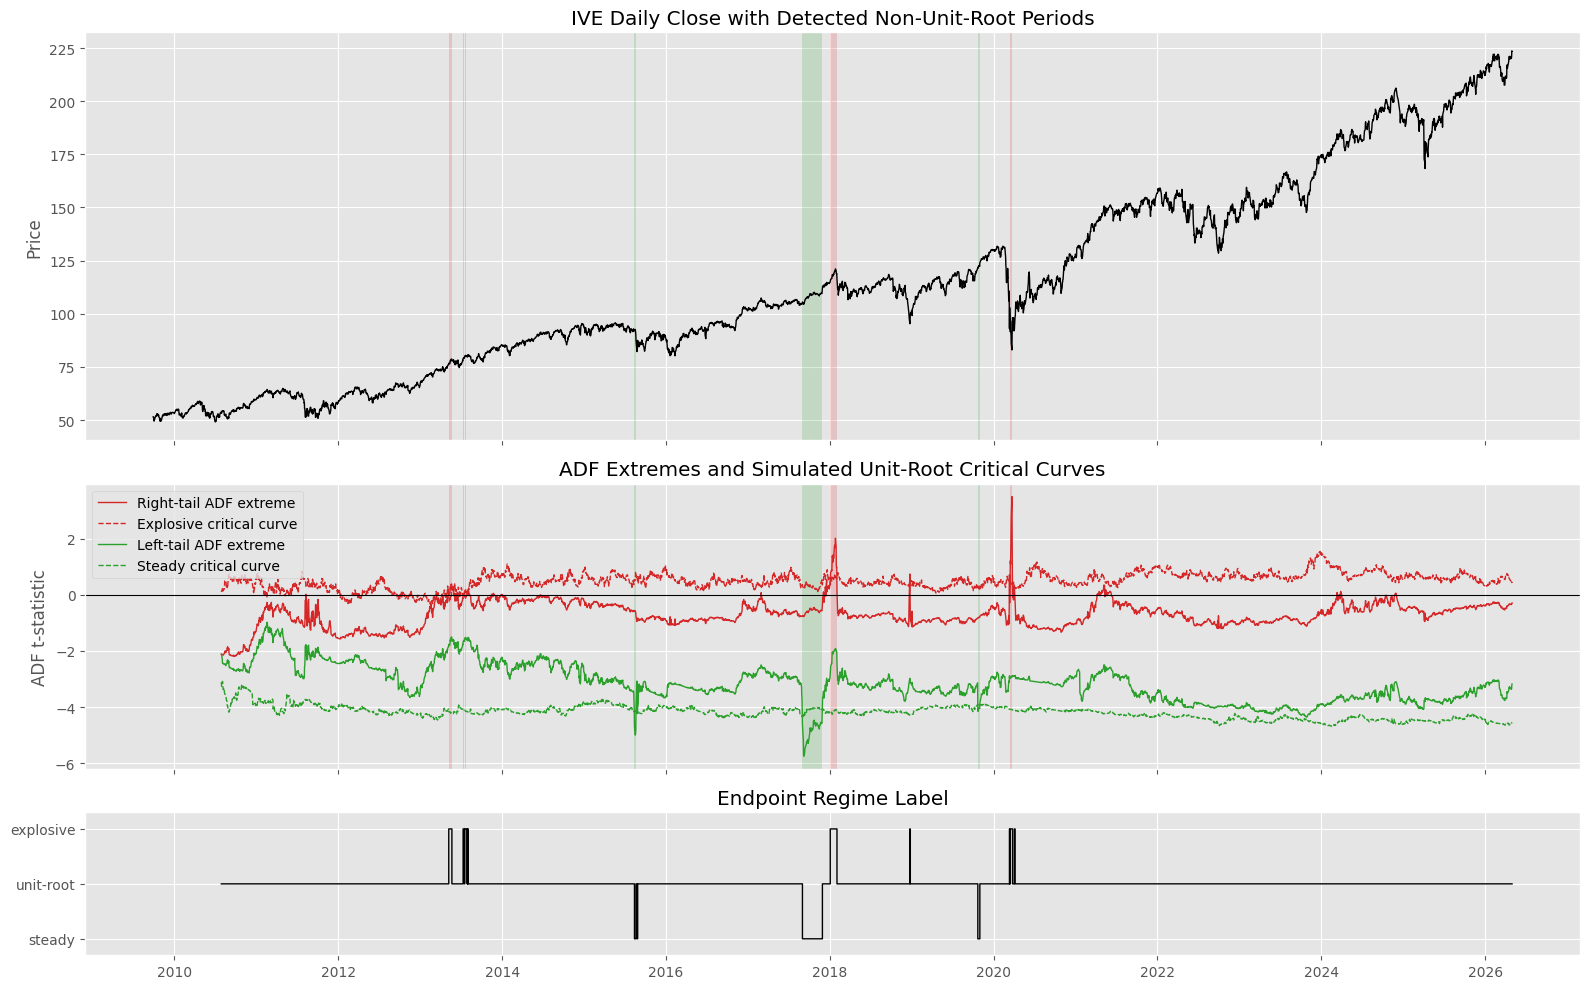

In [14]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1.4, 0.7]},
)

colors = {
    "steady": "tab:green",
    "unit-root": "tab:gray",
    "explosive": "tab:red",
}

axes[0].plot(sadf_data.index, sadf_data["price"], color="black", linewidth=1)
axes[0].set_title("IVE Daily Close with Detected Non-Unit-Root Periods")
axes[0].set_ylabel("Price")

for row in regime_periods_to_review.itertuples(index=False):
    for ax in axes[:2]:
        ax.axvspan(row.start, row.end, color=colors[row.regime], alpha=0.18, linewidth=0)

axes[1].plot(classified_regimes.index, classified_regimes["right_adf"], color="tab:red", linewidth=1, label="Right-tail ADF extreme")
axes[1].plot(classified_regimes.index, classified_regimes["right_critical"], color="tab:red", linestyle="--", linewidth=1, label="Explosive critical curve")
axes[1].plot(classified_regimes.index, classified_regimes["left_adf"], color="tab:green", linewidth=1, label="Left-tail ADF extreme")
axes[1].plot(classified_regimes.index, classified_regimes["left_critical"], color="tab:green", linestyle="--", linewidth=1, label="Steady critical curve")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("ADF Extremes and Simulated Unit-Root Critical Curves")
axes[1].set_ylabel("ADF t-statistic")
axes[1].legend(loc="upper left")

regime_codes = classified_regimes["regime"].map({"steady": -1, "unit-root": 0, "explosive": 1})
axes[2].plot(classified_regimes.index, regime_codes, color="black", linewidth=1, drawstyle="steps-post")
axes[2].set_yticks([-1, 0, 1])
axes[2].set_yticklabels(["steady", "unit-root", "explosive"])
axes[2].set_ylim(-1.3, 1.3)
axes[2].set_title("Endpoint Regime Label")

plt.tight_layout()
plt.show()


### b. Compute QADF.

QADF is now computed by the unified `supremum_adf_test` helper. It replaces the endpoint maximum in SADF with a high quantile of the endpoint ADF distribution. Here `qadf` is `Q[s_t, q]`, and `qadf_dispersion` is `Q[s_t, q + v] - Q[s_t, q - v]`.


Max difference versus previous SADF calculation: 0.000e+00
QADF q: 0.950
QADF dispersion band v: 0.025
Maximum QADF date: 2020-03-23
Maximum QADF value: 1.7653


,sadf,qadf,qadf_lower,qadf_upper,qadf_dispersion,n_adf_windows
2020-03-23,3.500576,1.765343,1.670983,3.145063,1.474080,2429
2020-03-20,2.748390,1.131417,1.061243,2.376186,1.314943,2428
2018-01-26,2.013080,0.828153,0.427896,1.592225,1.164328,1888
2018-01-29,1.716269,0.652820,0.300100,1.315062,1.014962,1889
2018-01-24,1.775272,0.640677,0.280631,1.354038,1.073408,1886
2018-01-25,1.683805,0.599430,0.262723,1.270011,1.007289,1887
2018-01-23,1.717789,0.590173,0.252594,1.284886,1.032292,1885
2018-01-22,1.744021,0.589810,0.250051,1.305939,1.055888,1884
2020-03-24,1.813494,0.574698,0.467966,1.529125,1.061159,2430
2020-03-19,1.980333,0.504453,0.430764,1.584048,1.153285,2427


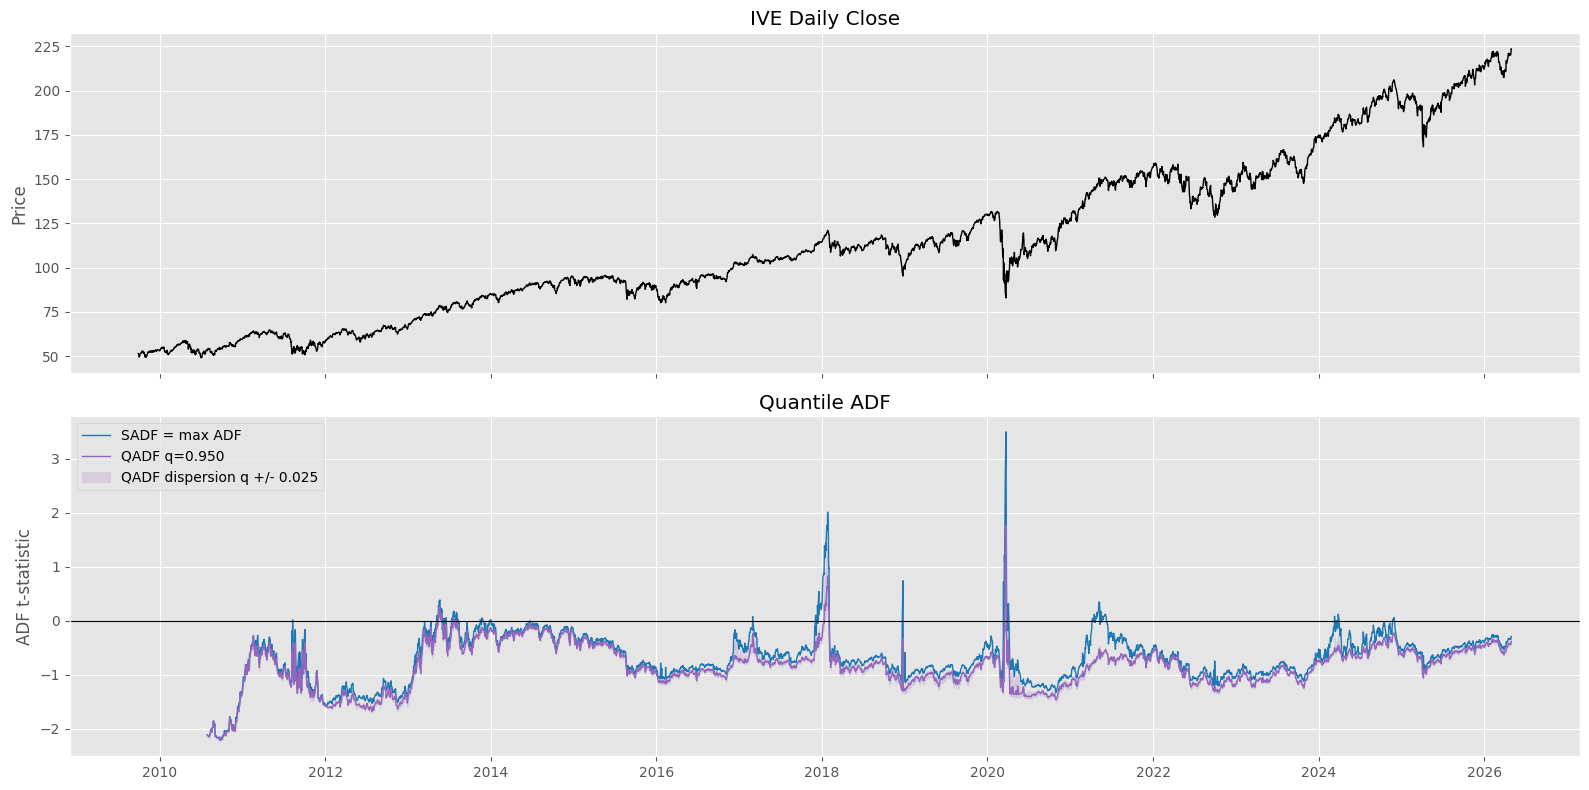

In [15]:
qadf_q = 0.95
qadf_v = 0.025
adf_tail_measures = supremum_adf_test(
    sadf_data["log_price"],
    min_length=sadf_min_length,
    lags=sadf_lags,
    q=qadf_q,
    v=qadf_v,
)

common_idx = adf_tail_measures.index.intersection(sadf.index)
sadf_check = (adf_tail_measures.loc[common_idx, "sadf"] - sadf.loc[common_idx, "sadf"]).abs().max()
print(f"Max difference versus previous SADF calculation: {sadf_check:.3e}")
print(f"QADF q: {qadf_q:.3f}")
print(f"QADF dispersion band v: {qadf_v:.3f}")
print(f"Maximum QADF date: {adf_tail_measures['qadf'].idxmax().date()}")
print(f"Maximum QADF value: {adf_tail_measures['qadf'].max():.4f}")

qadf_top = adf_tail_measures[
    ["sadf", "qadf", "qadf_lower", "qadf_upper", "qadf_dispersion", "n_adf_windows"]
].sort_values("qadf", ascending=False).head(10)
display(qadf_top)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(sadf_data.index, sadf_data["price"], color="black", linewidth=1)
axes[0].set_title("IVE Daily Close")
axes[0].set_ylabel("Price")

axes[1].plot(adf_tail_measures.index, adf_tail_measures["sadf"], color="tab:blue", linewidth=1, label="SADF = max ADF")
axes[1].plot(adf_tail_measures.index, adf_tail_measures["qadf"], color="tab:purple", linewidth=1, label=f"QADF q={qadf_q:.3f}")
axes[1].fill_between(
    adf_tail_measures.index,
    adf_tail_measures["qadf_lower"],
    adf_tail_measures["qadf_upper"],
    color="tab:purple",
    alpha=0.18,
    label=f"QADF dispersion q +/- {qadf_v:.3f}",
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Quantile ADF")
axes[1].set_ylabel("ADF t-statistic")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()


### c. Compute CADF.

CADF summarizes the right tail above `Q[s_t, q]`. In the empirical distribution, the conditional mean is the average of ADF t-statistics at or above the QADF threshold, and the conditional dispersion is their population standard deviation.


CADF q: 0.950
Maximum CADF date: 2020-03-23
Maximum CADF value: 2.8609
Largest standardized SADF-CADF gap date: 2024-12-05
Largest standardized SADF-CADF gap: 7.2497


,sadf,qadf,cadf,cadf_dispersion,sadf_cadf_z,tail_count,tail_probability
2020-03-23,3.500576,1.765343,2.860924,0.638396,1.001967,122,0.050226
2020-03-20,2.748390,1.131417,2.118219,0.594098,1.060718,122,0.050247
2018-01-26,2.013080,0.828153,1.547240,0.340915,1.366440,95,0.050318
2020-03-19,1.980333,0.504453,1.362307,0.541987,1.140296,122,0.050268
2020-03-24,1.813494,0.574698,1.343448,0.451019,1.042189,122,0.050206
2018-01-24,1.775272,0.640677,1.298502,0.343224,1.389093,95,0.050371
2018-01-29,1.716269,0.652820,1.282190,0.310007,1.400221,95,0.050291
2018-01-22,1.744021,0.589810,1.245330,0.361547,1.379324,95,0.050425
2018-01-23,1.717789,0.590173,1.233930,0.348107,1.389972,95,0.050398
2018-01-25,1.683805,0.599430,1.227434,0.324927,1.404533,95,0.050344


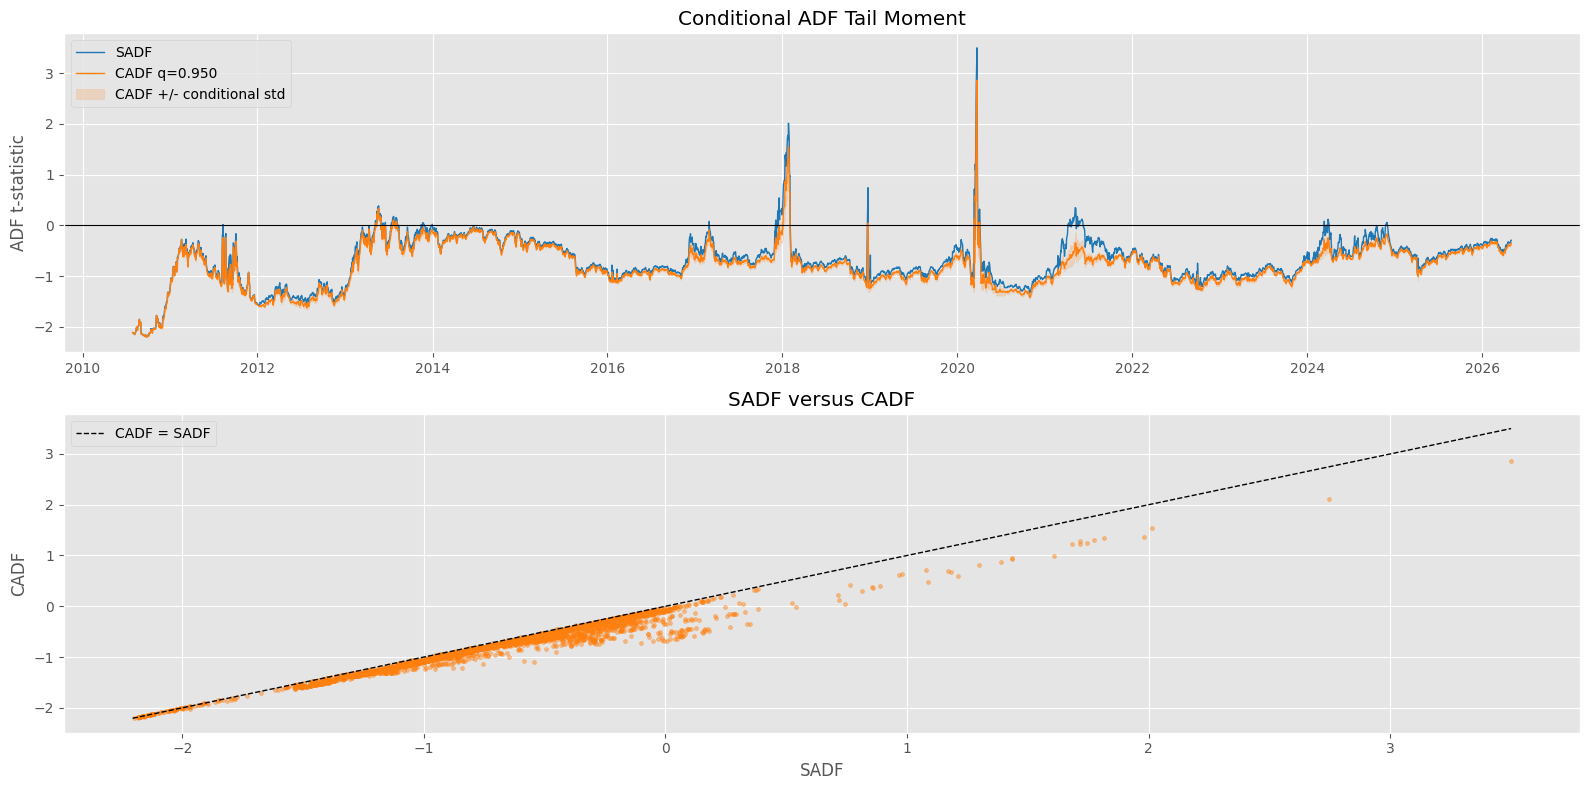

In [16]:
cadf_q = adf_tail_measures.attrs["q"]
max_cadf_date = adf_tail_measures["cadf"].idxmax()
max_gap_date = adf_tail_measures["sadf_cadf_z"].replace([np.inf, -np.inf], np.nan).idxmax()

print(f"CADF q: {cadf_q:.3f}")
print(f"Maximum CADF date: {max_cadf_date.date()}")
print(f"Maximum CADF value: {adf_tail_measures.loc[max_cadf_date, 'cadf']:.4f}")
print(f"Largest standardized SADF-CADF gap date: {max_gap_date.date()}")
print(f"Largest standardized SADF-CADF gap: {adf_tail_measures.loc[max_gap_date, 'sadf_cadf_z']:.4f}")

cadf_top = adf_tail_measures[
    ["sadf", "qadf", "cadf", "cadf_dispersion", "sadf_cadf_z", "tail_count", "tail_probability"]
].sort_values("cadf", ascending=False).head(10)
display(cadf_top)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

axes[0].plot(adf_tail_measures.index, adf_tail_measures["sadf"], color="tab:blue", linewidth=1, label="SADF")
axes[0].plot(adf_tail_measures.index, adf_tail_measures["cadf"], color="tab:orange", linewidth=1, label=f"CADF q={cadf_q:.3f}")
axes[0].fill_between(
    adf_tail_measures.index,
    adf_tail_measures["cadf"] - adf_tail_measures["cadf_dispersion"],
    adf_tail_measures["cadf"] + adf_tail_measures["cadf_dispersion"],
    color="tab:orange",
    alpha=0.18,
    label="CADF +/- conditional std",
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Conditional ADF Tail Moment")
axes[0].set_ylabel("ADF t-statistic")
axes[0].legend(loc="upper left")

axes[1].scatter(adf_tail_measures["sadf"], adf_tail_measures["cadf"], s=8, alpha=0.45, color="tab:orange")
finite_pair = adf_tail_measures[["sadf", "cadf"]].replace([np.inf, -np.inf], np.nan).dropna()
line_min = finite_pair.min().min()
line_max = finite_pair.max().max()
axes[1].plot([line_min, line_max], [line_min, line_max], color="black", linestyle="--", linewidth=1, label="CADF = SADF")
axes[1].set_title("SADF versus CADF")
axes[1].set_xlabel("SADF")
axes[1].set_ylabel("CADF")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

## 4. On a dollar bar series on E-mini S&P 500 futures,

### a. Compute SMT for SM-Poly1 and SM-Poly 2, where φ = 1. What is their  correlation?

In [17]:
smt_phi = 1.0
smt_min_length = sadf_min_length

smt = sub_super_martingale_test(
    sadf_data["price"],
    min_length=smt_min_length,
    phi=smt_phi,
    trends="all",
)

smt_summary_rows = []
for trend in smt.attrs["trends"]:
    smt_col = f"{trend}_smt"
    max_date = smt[smt_col].idxmax()
    smt_summary_rows.append(
        {
            "trend": trend,
            "max_date": max_date,
            "max_smt": smt.loc[max_date, smt_col],
            "window_start": smt.loc[max_date, f"{trend}_start"],
            "window_observations": int(smt.loc[max_date, f"{trend}_nobs"]),
            "elapsed": int(smt.loc[max_date, f"{trend}_elapsed"]),
            "t_stat": smt.loc[max_date, f"{trend}_t_stat"],
        }
    )

smt_summary = pd.DataFrame(smt_summary_rows)
poly1_poly2_corr = smt[["poly1_smt", "poly2_smt"]].corr().iloc[0, 1]

print(f"SMT phi: {smt.attrs['phi']:.1f}")
print(f"Minimum SMT window length: {smt.attrs['min_length']:,}")
print(f"Poly1/Poly2 SMT correlation: {poly1_poly2_corr:.4f}")
display(smt_summary)


SMT phi: 1.0
Minimum SMT window length: 209
Poly1/Poly2 SMT correlation: 0.9753


,trend,max_date,max_smt,window_start,window_observations,elapsed,t_stat
0,poly1,2011-10-04,0.151857,2010-11-12,225,224,-34.016053
1,poly2,2011-10-05,0.150063,2010-11-12,226,225,-33.764164
2,exp,2026-03-04,0.322649,2025-05-05,209,208,67.110926
3,power,2026-03-04,0.326278,2025-05-05,209,208,67.865878


In [19]:
smt.head()

,poly1_smt,poly1_start,poly1_start_loc,poly1_end_loc,poly1_beta,poly1_beta_se,poly1_t_stat,poly1_nobs,poly1_elapsed,poly2_smt,...,exp_elapsed,power_smt,power_start,power_start_loc,power_end_loc,power_beta,power_beta_se,power_t_stat,power_nobs,power_elapsed
2010-07-27,0.051585,2009-09-28,0,208,-0.000402,0.000037,-10.729613,209.0,208.0,0.052175,...,208.0,0.029162,2009-09-28,0,208,0.017067,0.002814,6.065687,209.0,208.0
2010-07-28,0.051711,2009-09-29,1,209,-0.000403,0.000037,-10.755992,209.0,208.0,0.052263,...,209.0,0.029156,2009-09-29,1,209,0.017909,0.002953,6.064413,209.0,208.0
2010-07-29,0.051888,2009-09-30,2,210,-0.000404,0.000037,-10.792794,209.0,208.0,0.052403,...,210.0,0.028924,2009-09-29,1,210,0.017777,0.002941,6.045080,210.0,209.0
2010-07-30,0.051839,2009-10-01,3,211,-0.000403,0.000037,-10.782488,209.0,208.0,0.052306,...,211.0,0.028701,2009-09-29,1,211,0.017649,0.002928,6.027253,211.0,210.0
2010-08-02,0.050852,2009-10-01,3,212,-0.000394,0.000037,-10.628067,210.0,209.0,0.051269,...,212.0,0.028702,2009-09-29,1,212,0.017644,0.002913,6.056080,212.0,211.0


### b. Compute SMT for SM-Exp, where φ = 1 and φ = 0.5. What is their correlation?

In [21]:
smt_exp_0p5 = sub_super_martingale_test(
    sadf_data["price"],
    min_length=smt_min_length,
    phi=0.5,
    trends="exp",
)

smt_exp_1 = sub_super_martingale_test(
    sadf_data["price"],
    min_length=smt_min_length,
    phi=1.0,
    trends="exp",
)

smt_exp_0p5_1_corr = np.corrcoef(smt_exp_0p5["exp_smt"], smt_exp_1["exp_smt"])[0, 1]

print(f"The correlation between the SMT for φ = 0.5 and φ = 1 is {smt_exp_0p5_1_corr:.4f}")

The correlation between the SMT for φ = 0.5 and φ = 1 is 0.5281


### c. Compute SMT for SM-Power, where φ = 1 and φ = 0.5. What is their correlation?

In [22]:
smt_power_0p5 = sub_super_martingale_test(
    sadf_data["price"],
    min_length=smt_min_length,
    phi=0.5,
    trends="power",
)

smt_power_1 = sub_super_martingale_test(
    sadf_data["price"],
    min_length=smt_min_length,
    phi=1.0,
    trends="power",
)

smt_power_0p5_1_corr = np.corrcoef(smt_power_0p5["power_smt"], smt_power_1["power_smt"])[0, 1]

print(f"The correlation between the SMT Power Trend for φ = 0.5 and φ = 1 is {smt_power_0p5_1_corr:.4f}")

The correlation between the SMT Power Trend for φ = 0.5 and φ = 1 is 0.6419


## 5. If you compute the reciprocal of each price, the series $y_t^{-1}$ turns bubbles into bursts and bursts into bubbles.

### a. Is this transformation needed, to identify bursts?

Not universally. The reciprocal transformation is needed when the test is one-sided for upward explosiveness, because a price collapse is not an upward explosive episode in the original price or log-price series. Applying the same right-tail test to $1 / y_t$ converts the collapse into an upward move in the transformed series.

If the method is already two-sided, uses an absolute-value statistic, or is explicitly modified to use the lower tail, then the reciprocal transformation is not mechanically required. In that case the sign of the fitted coefficient or test statistic should still be inspected to distinguish a bubble from a burst.

### b. What methods in this chapter can identify bursts without requiring this transformation?

The Sub-/Super-Martingale Tests (SMT) are the cleanest methods in this chapter for identifying bursts without the reciprocal transformation. Their statistic is based on an absolute t-statistic, so both upward and downward explosive departures can be flagged; the sign of the selected trend coefficient or t-statistic tells whether the episode is bubble-like or burst-like.

The Brown-Durbin-Evans CUSUM test can also detect structural instability in either direction because it uses upper and lower CUSUM bands, although it is a general stability test rather than a burst-specific classifier.

By contrast, the standard CSW, SDFC, SADF, QADF, and CADF implementations used above are right-tail explosiveness statistics. They do not identify bursts from the original series just because $\Delta \log(1 / y_t) = -\Delta \log(y_t)$. To use them for bursts without taking reciprocals, we would need an explicit left-tail or infimum version of the statistic and appropriate critical values.